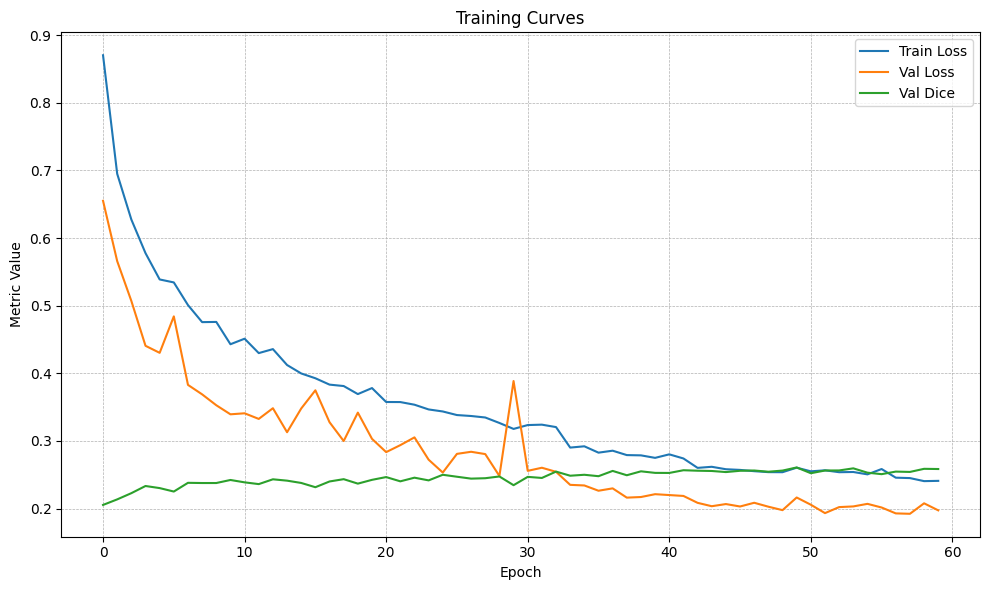

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
txt_path = "log_filip.txt"
with open(txt_path, "r", encoding="utf-8") as f:
    text = f.read()

# Regex to capture epoch, train loss, val loss, val dice.
pattern = re.compile(
    r"Epoch\s+(\d+)\s.*?Train Loss:\s*([0-9.]+)\s*\|\s*Val Loss:\s*([0-9.]+)\s*\|\s*Val Dice:\s*([0-9.]+)"
)

rows = []
for m in pattern.finditer(text):
    epoch, tr, vl, vd = m.groups()
    rows.append((int(epoch), float(tr), float(vl), float(vd)))

# Build DataFrame
df = pd.DataFrame(rows, columns=["Epoch", "Train Loss", "Val Loss", "Val Dice"]).sort_values("Epoch")


# Plot the three curves in a single chart (no subplots), and save it.
plt.figure(figsize=(10, 6))
plt.plot(df["Epoch"], df["Train Loss"], label="Train Loss")
plt.plot(df["Epoch"], df["Val Loss"], label="Val Loss")
plt.plot(df["Epoch"], df["Val Dice"], label="Val Dice")
plt.title("Training Curves")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.show()